# DecodeLabs Data Analytics Internship

## Project 2: Exploratory Data Analysis (EDA)

### Objective

The objective of this project is to analyze an e-commerce dataset to identify patterns, trends, distributions, and business insights through exploratory data analysis.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
df = pd.read_excel(r"C:\Users\REAL TIME\Downloads\Dataset for Data Analytics P2.xlsx")

In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
df.shape

(1200, 14)

## Dataset Understanding

The dataset contains 1,200 records and 14 columns. Each record represents a customer order and includes information such as order details, customer identifiers, products purchased, quantities, payment methods, referral sources, order status, and total transaction value.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

The dataset was inspected for data quality issues before analysis. A review of missing values showed that the CouponCode field contained missing entries, which likely represent orders where no coupon was applied. No major data quality issues affecting the analysis were identified.

## Descriptive Statistics

To better understand the dataset, descriptive statistics were generated for all numerical variables. This provides information about the distribution, central tendency, and variability of the data.

The analysis focuses on key business metrics such as Quantity, UnitPrice, ItemsInCart, and TotalPrice.

In [7]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


### Statistical Findings

The average order value was $1,053.97, while the median order value was $823.62. Since the mean is higher than the median, the distribution appears positively skewed, indicating that a small number of high-value transactions increase the overall average.

Order values ranged from $11.39 to $3,456.40, showing substantial variation in customer spending behavior. The standard deviation of $819.86 further confirms the presence of wide differences in transaction values.

In [8]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

## Missing Value Analysis

Missing values were assessed to determine whether any columns contained incomplete data that could affect the quality of the analysis.

In [9]:
(309 / 1200) * 100

25.75

### Missing Value Findings

The dataset contains very few missing values. The only column with missing data is CouponCode, which has 309 missing entries.

These missing values are likely valid observations representing orders where customers did not apply a coupon during checkout. Therefore, no imputation or removal was required, and the column was retained for analysis.

All other variables were complete, indicating a high-quality dataset suitable for exploratory analysis.

In [18]:
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

product_sales

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

## Product Revenue Analysis

To identify the best-performing products, total revenue was calculated for each product category. This analysis helps determine which products contribute most to overall sales.

### Findings

Chairs generated the highest revenue, closely followed by Printers and Laptops. Revenue was relatively balanced among the top-performing products, suggesting that sales are not dependent on a single product category.

Phones generated the lowest revenue among the listed products, indicating potential opportunities for marketing or sales improvement.

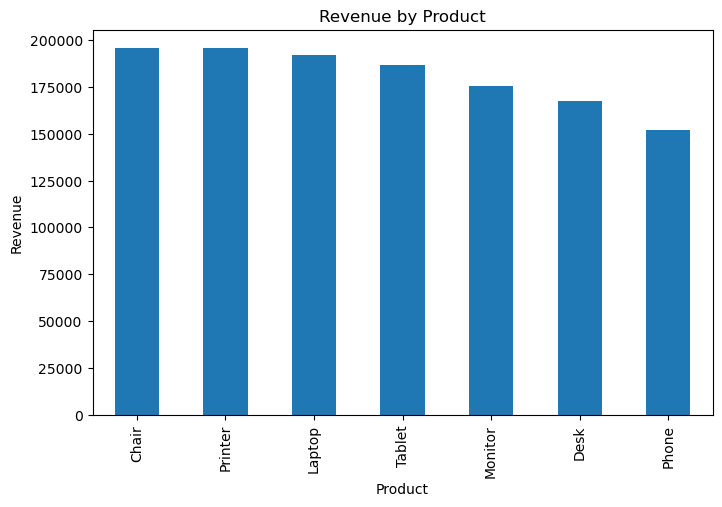

In [19]:
product_sales.plot(kind='bar', figsize=(8,5))

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

### Visualization Insight

The bar chart shows that Chairs and Printers generated the highest revenue, while Phones generated the lowest. Revenue is relatively evenly distributed across product categories, suggesting a balanced product portfolio with no single product dominating sales.

## Order Status Analysis

Order status distribution was analyzed to understand the operational performance of the business and identify the frequency of completed, pending, cancelled, and returned orders.

In [20]:
order_status = df['OrderStatus'].value_counts()

order_status

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

### Findings

Cancelled orders were the most common order status, followed closely by Returned and Pending orders. Delivered orders represented the smallest category.

The distribution of order statuses is relatively balanced, with only small differences between categories. However, the high number of cancelled and returned orders may indicate potential operational or customer satisfaction challenges that warrant further investigation.

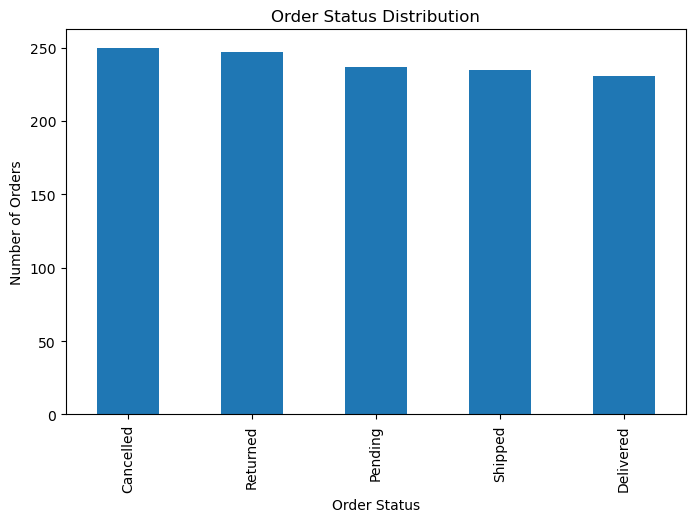

In [21]:
order_status.plot(kind='bar', figsize=(8,5))

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

### Visualization Insight

The order status distribution is relatively balanced across all categories. Cancelled orders were the most frequent status, while Delivered orders were the least frequent.

The small differences between categories suggest that no single order status dominates the dataset. However, the proportion of cancelled and returned orders may indicate areas for operational improvement.

## Payment Method Analysis

Payment methods were analyzed to understand customer transaction preferences and identify the most commonly used payment channels.

In [22]:
payment_method = df['PaymentMethod'].value_counts()

payment_method

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

### Findings

Online payments were the most frequently used payment method, followed by Cash and Credit Card transactions.

The distribution across payment methods is relatively balanced, indicating that customers utilize a variety of payment options and that no single payment channel dominates customer transactions.

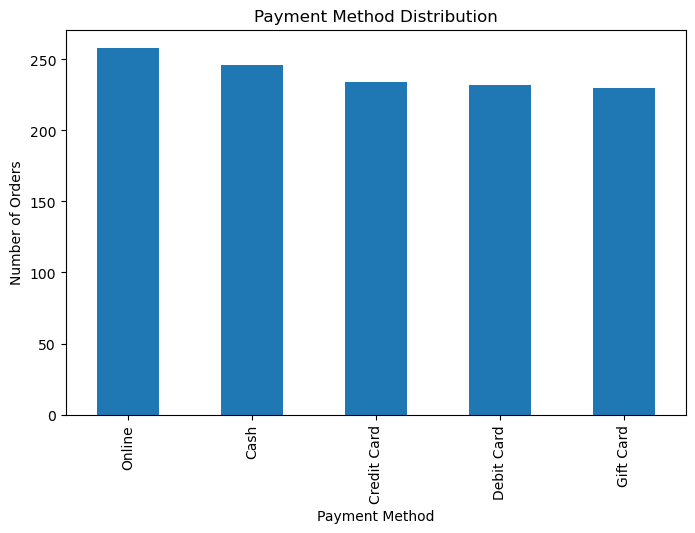

In [23]:
payment_method.plot(kind='bar', figsize=(8,5))

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.show()

## Revenue by Referral Source

Referral sources were analyzed to determine which marketing channels generated the highest revenue. Understanding customer acquisition channels helps businesses allocate marketing resources more effectively.

In [24]:
referral_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

referral_revenue

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

### Findings

Instagram generated the highest revenue among all referral sources, followed by Email marketing. Google and Facebook produced nearly identical revenue figures, while Referral generated the lowest revenue.

These results suggest that social media and email marketing channels play a significant role in driving sales and customer engagement.

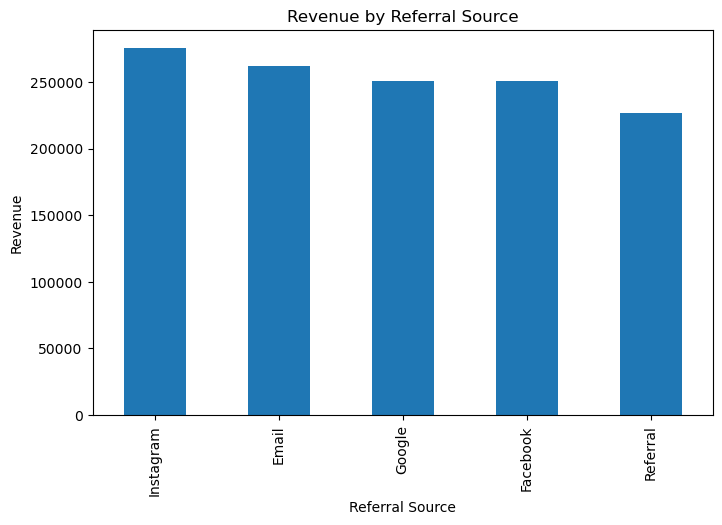

In [25]:
referral_revenue.plot(kind='bar', figsize=(8,5))

plt.title("Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Revenue")
plt.show()

In [26]:
df['Month'] = df['Date'].dt.to_period('M')

In [27]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.head()

Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
Freq: M, Name: TotalPrice, dtype: float64

## Monthly Revenue Trend

Monthly revenue analysis was performed to identify revenue patterns over time and detect periods of high or low sales performance.

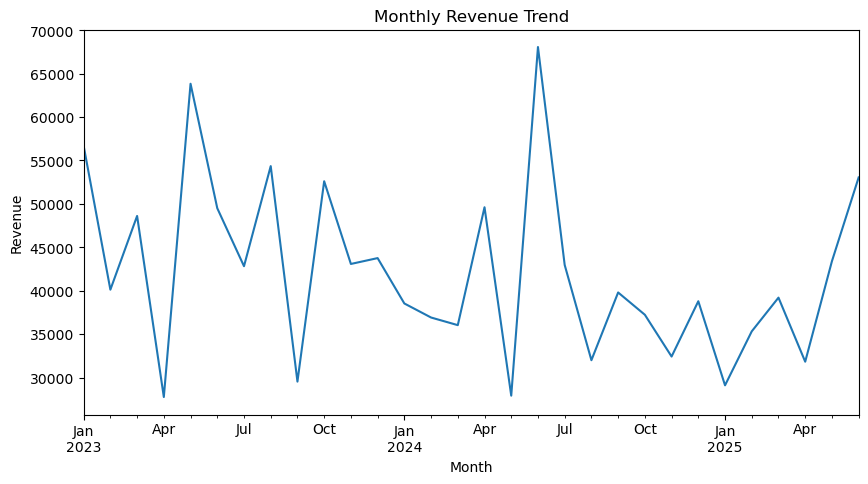

In [28]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### Findings

Monthly revenue fluctuated throughout the analysis period, indicating varying customer demand over time.

The highest revenue was recorded around mid-2024, while several months experienced noticeably lower sales performance. These fluctuations suggest possible seasonal effects, promotional impacts, or changes in customer purchasing behavior.

In [29]:
df['OrderID'].duplicated().sum()

np.int64(0)

In [30]:
df['Date'].dtype

dtype('<M8[ns]')

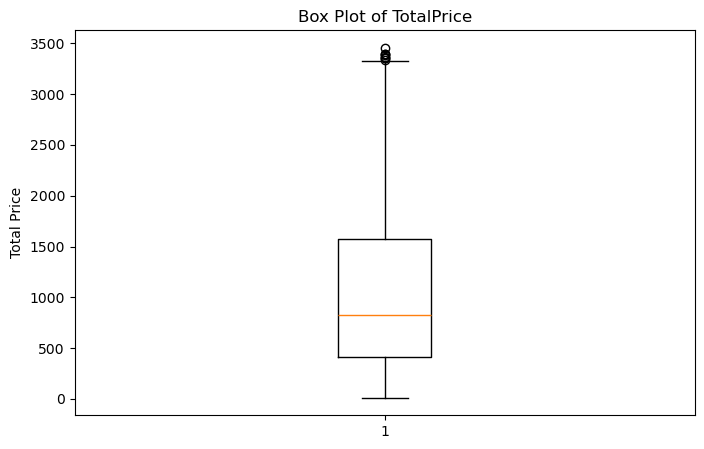

In [31]:
plt.figure(figsize=(8,5))
plt.boxplot(df['TotalPrice'])
plt.title("Box Plot of TotalPrice")
plt.ylabel("Total Price")
plt.show()

### Outlier Analysis

A box plot of TotalPrice was used to identify outliers.

Findings:
- Most customer orders fall within a moderate spending range.
- Several high-value transactions were detected above the upper whisker.
- These outliers likely represent customers purchasing multiple high-priced items rather than data entry errors.
- No extreme negative or invalid values were observed.

## Key Observations

1. Chair generated the highest revenue, while Phone generated the lowest revenue among the listed products.

2. Order statuses were fairly balanced, although Cancelled orders were slightly more common than Delivered orders.

3. Online payments were the most frequently used payment method.

4. Instagram generated the highest revenue among referral sources, indicating strong customer acquisition performance.

5. Monthly revenue fluctuated over time, with noticeable peaks and dips that may reflect seasonal purchasing behavior.

6. A small number of high-value transactions were identified as outliers in the TotalPrice distribution.